In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)
n = 1500
traffic_volume = np.random.randint(100, 1000, n)
average_speed = np.round(
    np.random.uniform(10, 80, n), 2
)
temperature = np.round(
    np.random.uniform(15, 40, n), 2
)
humidity = np.round(
    np.random.uniform(30, 95, n), 2
)
rainfall = np.round(
    np.random.uniform(0, 20, n), 2
)
hour = np.random.randint(0, 24, n)
day_of_week = np.random.randint(0, 7, n)
data = pd.DataFrame({
    "Traffic_Volume": traffic_volume,
    "Average_Speed": average_speed,
    "Temperature": temperature,
    "Humidity": humidity,
    "Rainfall": rainfall,
    "Hour": hour,
    "Day_of_Week": day_of_week
})
print(data.head())

   Traffic_Volume  Average_Speed  Temperature  Humidity  Rainfall  Hour  \
0             202          14.70        30.90     57.15     14.66    14   
1             535          62.50        37.83     37.56     19.91    15   
2             960          24.69        30.31     69.83      5.75     6   
3             370          72.86        36.84     91.00     10.76    16   
4             206          24.36        33.10     73.02     10.67    18   

   Day_of_Week  
0            3  
1            0  
2            5  
3            3  
4            3  


In [3]:
traffic_score = (
    0.45 * traffic_volume
    - 5 * average_speed
    + 2 * rainfall
    + 10 * ((hour >= 7) & (hour <= 10))
    + 10 * ((hour >= 17) & (hour <= 20))
)
congestion_level = np.where(
    traffic_score < 150,
    "Low",
    np.where(
        traffic_score < 350,
        "Medium",
        "High"
    )
)
data["Congestion_Level"] = congestion_level
print(data.head())

   Traffic_Volume  Average_Speed  Temperature  Humidity  Rainfall  Hour  \
0             202          14.70        30.90     57.15     14.66    14   
1             535          62.50        37.83     37.56     19.91    15   
2             960          24.69        30.31     69.83      5.75     6   
3             370          72.86        36.84     91.00     10.76    16   
4             206          24.36        33.10     73.02     10.67    18   

   Day_of_Week Congestion_Level  
0            3              Low  
1            0              Low  
2            5           Medium  
3            3              Low  
4            3              Low  


In [4]:
print("Dataset Shape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nStatistical Summary:")
print(data.describe())

Dataset Shape:
(1500, 8)

Columns:
Index(['Traffic_Volume', 'Average_Speed', 'Temperature', 'Humidity',
       'Rainfall', 'Hour', 'Day_of_Week', 'Congestion_Level'],
      dtype='str')

Missing Values:
Traffic_Volume      0
Average_Speed       0
Temperature         0
Humidity            0
Rainfall            0
Hour                0
Day_of_Week         0
Congestion_Level    0
dtype: int64

Statistical Summary:
       Traffic_Volume  Average_Speed  Temperature     Humidity     Rainfall  \
count     1500.000000    1500.000000  1500.000000  1500.000000  1500.000000   
mean       554.050667      44.951973    27.436247    62.008447     9.942587   
std        267.604345      20.360075     7.206284    18.718544     5.784036   
min        100.000000      10.110000    15.000000    30.000000     0.030000   
25%        317.000000      26.785000    21.277500    45.922500     4.887500   
50%        558.000000      45.555000    27.315000    61.440000     9.860000   
75%        788.000000      62.435

In [5]:
print(data["Congestion_Level"].value_counts())

Congestion_Level
Low       1077
Medium     393
High        30
Name: count, dtype: int64


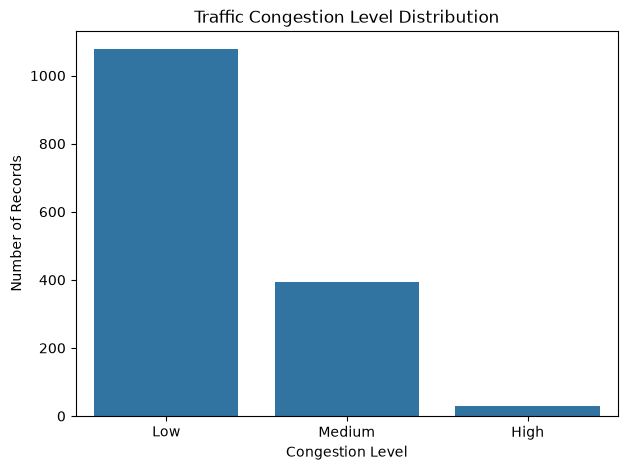

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Congestion_Level"
)

plt.title("Traffic Congestion Level Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Number of Records")

plt.show()

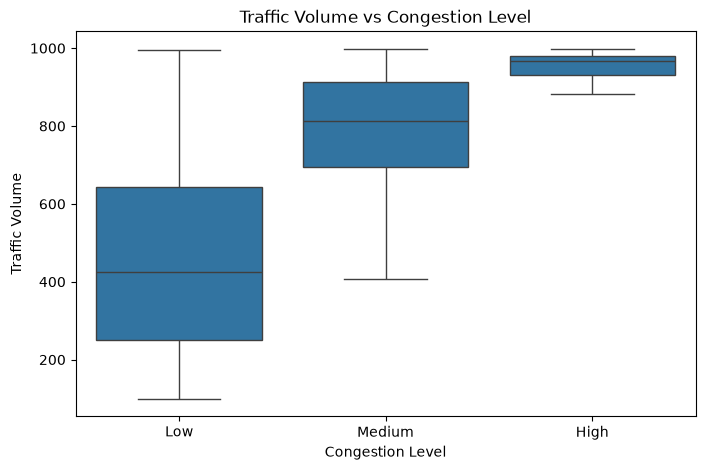

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Congestion_Level",
    y="Traffic_Volume"
)

plt.title("Traffic Volume vs Congestion Level")
plt.xlabel("Congestion Level")
plt.ylabel("Traffic Volume")

plt.show()

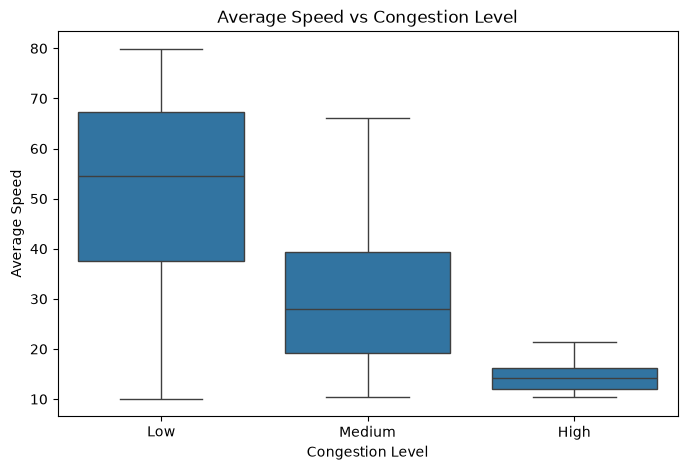

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Congestion_Level",
    y="Average_Speed"
)

plt.title("Average Speed vs Congestion Level")
plt.xlabel("Congestion Level")
plt.ylabel("Average Speed")

plt.show()

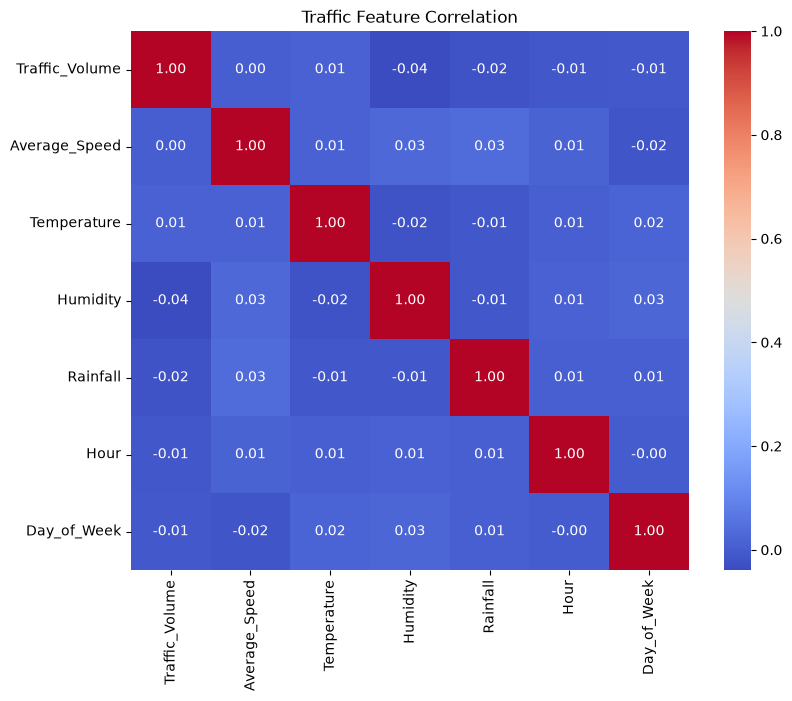

In [9]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Traffic Feature Correlation")

plt.show()

In [10]:
label_encoder = LabelEncoder()

data["Congestion_Encoded"] = label_encoder.fit_transform(
    data["Congestion_Level"]
)

print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [11]:
X = data[
    [
        "Traffic_Volume",
        "Average_Speed",
        "Temperature",
        "Humidity",
        "Rainfall",
        "Hour",
        "Day_of_Week"
    ]
]

y = data["Congestion_Encoded"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Traffic_Volume  Average_Speed  Temperature  Humidity  Rainfall  Hour  \
0             202          14.70        30.90     57.15     14.66    14   
1             535          62.50        37.83     37.56     19.91    15   
2             960          24.69        30.31     69.83      5.75     6   
3             370          72.86        36.84     91.00     10.76    16   
4             206          24.36        33.10     73.02     10.67    18   

   Day_of_Week  
0            3  
1            0  
2            5  
3            3  
4            3  

Target:
0    1
1    1
2    2
3    1
4    1
Name: Congestion_Encoded, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1200, 7)
Testing data: (300, 7)


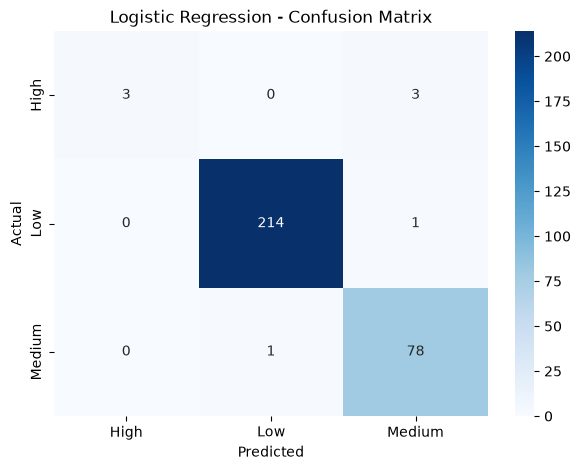

In [14]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

KNN Classification completed!
KNN Accuracy: 0.89


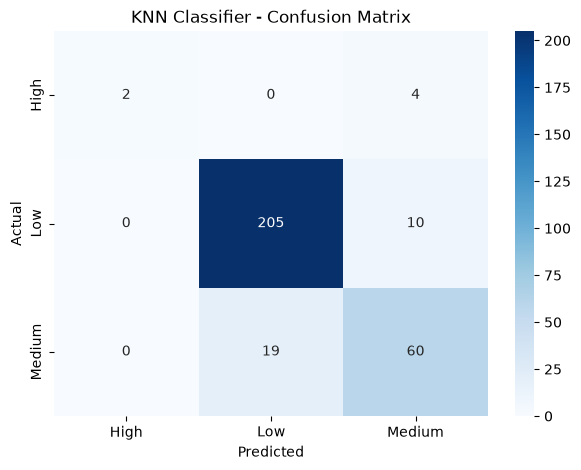

In [16]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print("KNN Classification completed!")
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_accuracy)
cm = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("KNN Classifier - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Classification completed!
Decision Tree Accuracy: 0.96


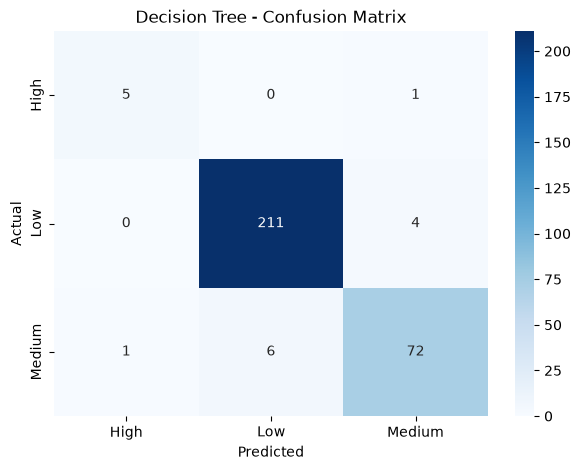

In [20]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

decision_tree_pred = decision_tree_model.predict(X_test)

print("Decision Tree Classification completed!")

dt_accuracy = accuracy_score(
    y_test,
    decision_tree_pred
)

print("Decision Tree Accuracy:", dt_accuracy)

cm = confusion_matrix(
    y_test,
    decision_tree_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()